In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from helper import train_loop
from helper import fashionClassifierMLP
from helper import get_data
from helper import labels_map

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"Using {device} device")


Using mps device


torch.Size([28, 28])
9


/Users/ignacio/nn/.venv/lib/python3.12/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


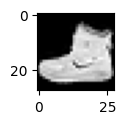

torch.Size([28, 28])
0


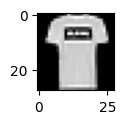

In [2]:
# print first sample of the training data
training_data, test_data = get_data()
print(training_data.data[0].shape)
print(training_data.train_labels[0].item())
# show image
# height of 100px and width of 100px
plt.figure(figsize=(1, 1))
plt.imshow(training_data.data[0], cmap="gray")
plt.show()

# print second image
print(training_data.data[1].shape)
print(training_data.train_labels[1].item())
# show image
plt.figure(figsize=(1, 1))
plt.imshow(training_data.data[1], cmap="gray")
plt.show()

In [3]:
# split train dataset into train+validation
training_data, validation_data = torch.utils.data.random_split(training_data, [50000, 10000])

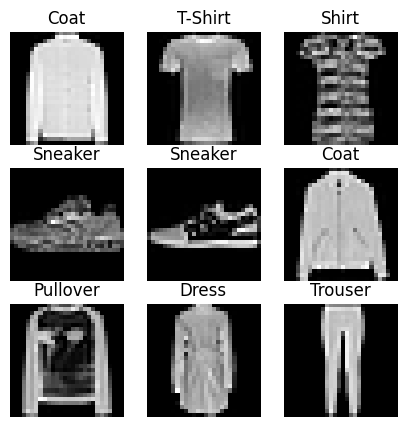

In [4]:

figure = plt.figure(figsize=(5, 5))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [5]:
batch_size = 128

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

for X, y in test_dataloader:
    # N is the batch size
    # C is the classification label
    # H and W are height and width
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([128, 1, 28, 28])
Shape of y: torch.Size([128]) torch.int64


In [6]:

model = fashionClassifierMLP().to(device)
print(model)

fashionClassifierMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:

model.train()
epochs = 200
lossFn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, weight_decay=1e-4)


train_loop(epochs, train_dataloader, model, lossFn, optimizer, device)

# evaluate the model on the evaluation dataset
model.eval()
size = len(validation_data)
num_batches = len(test_dataloader)
test_loss, correct = 0, 0
with torch.inference_mode():
    for image, expected_label in test_dataloader:
        pred = model(image)
        test_loss += lossFn(pred, expected_label).item()
        correct += (pred.argmax(1) == expected_label).type(torch.float).sum().item()



epoch 0 loss 2.3059055805206332
epoch 1 loss 2.2948031425476074
epoch 2 loss 2.29828143119812
epoch 3 loss 2.300530195236206
epoch 4 loss 2.2849299907684326
epoch 5 loss 2.274869441986084
epoch 6 loss 2.2545552253723145
epoch 7 loss 2.2596652507781982
epoch 8 loss 2.2687056064605713
epoch 9 loss 2.2567503452301025
epoch 10 loss 2.2424366474151615
epoch 11 loss 2.2344613075256348
epoch 12 loss 2.2522072792053223
epoch 13 loss 2.239058256149292
epoch 14 loss 2.2256085872650146
epoch 15 loss 2.224605083465576
epoch 16 loss 2.2170372009277344
epoch 17 loss 2.2353782653808594
epoch 18 loss 2.2185606956481934
